# **FICO® Xpress MoselPy - Chapter G: Telecommunications**

***telecomm.ipynb*** - Telecommunications network design problems from the Xpress Applications Book - network reliability, mobile network dimensioning, call routing, cable networks, satellite scheduling, and transmitter placement, solved with MoselPy.

&copy; Copyright 2026 Fair Isaac Corporation. The use of this example is subject to [legal and license requirements](https://github.com/fico-xpress/xpress-community#legal-and-license-requirements).

In [ ]:
# Install the necessary packages
%pip install -q moselpy mosellibs xpresslibs matplotlib pandas

Run the cell below to import the necessary libraries and set `MODELS` and `DATA`, the path variables pointing to the Mosel model files and data files used in this notebook.

In [ ]:
# On Linux, preload the Xpress solver library so the Mosel optimizer module
# (mmxprs) can resolve it at runtime.
import sys, os, glob, ctypes, xpresslibs
if sys.platform == "linux":
    for _lib in glob.glob(os.path.join(xpresslibs.solver_libs_dir, "libxprs.so*")):
        ctypes.CDLL(_lib, mode=ctypes.RTLD_GLOBAL)

import moselpy as mp
from moselpy import ExecStatus
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

MODELS = "models/telecomm"
DATA   = "data/telecomm"

print(f"MoselPy {mp.version}  |  Mosel {mp.mosel_version}  |  Xpress {mp.xpress_version}")
mp.config.set_default_stream(mp.StreamType.OUTPUT, "null:")

MoselPy 6.12.0  |  Mosel 6012000  |  Xpress 10000000


## Telecommunications network design

This notebook covers six LP and MIP examples from Chapter G of the Xpress Applications Book, solved via [MoselPy](https://pypi.org/project/moselpy/). Examples span network reliability analysis, mobile network dimensioning, telephone call routing, cable network design, satellite scheduling, and transmitter placement.

> **Mosel source files:** [`models/telecomm/`](models/telecomm/) &nbsp;|&nbsp; **Data files:** [`data/telecomm/`](data/telecomm/)

> **Requirements:** `pip install moselpy mosellibs xpresslibs` - `mosellibs` provides the Mosel runtime and `xpresslibs` the Xpress solver libraries. No local Xpress installation is needed to run these notebooks, as long as the packages with libraries have been installed.

> A local FICO&reg; Xpress installation is recommended if you want access to the full set of examples, user guides and documentation, solver libraries, and Xpress Workbench. Obtain one via the [FICO&reg; Xpress community license](https://www.fico.com/en/fico-xpress-community-license) page. If a local installation is present, set `XPRESSDIR` before starting Jupyter to use it instead of the `mosellibs` and `xpresslibs` packages.

> **MoselPy documentation:** [MoselPy User Guide and Reference Manual](https://www.fico.com/fico-xpress-optimization/docs/latest/mosel/MoselPy/dhtml)

> **Mosel examples on the web:** [examples.xpress.fico.com](https://examples.xpress.fico.com/example.pl?id=mosel_app_7)

### MoselPy features demonstrated in this chapter

- **Dynamic sparse arrays**: G-1 uses Mosel `dynamic array` with `exists()` and `create()` to build flow variables only for existing network arcs. MoselPy reads these from a sparse Python dict automatically.
- **`pd.DataFrame` for 2D cost input**: G-2 passes a 10x5 cost matrix as a DataFrame; MoselPy maps rows and columns to the Mosel 2D array index.
- **Two consecutive `initializations from` blocks**: G-3 reads arc capacities and demands first, computes the number of arcs dynamically, then reads the route array in a second block - both from the same Python `input_data` dict.
- **Model introspection before running**: G-4 calls `model.name`, `model.version`, and `model.size` after `load_model()` but before `run()`.
- **Context manager + iterative in-Mosel algorithm**: G-5 uses `with mp.load_model(...) as model:` and runs an iterative scheduling algorithm that modifies and re-solves inside Mosel, returning the complete schedule to Python.
- **`exec_params` sensitivity loop**: G-6 varies `BUDGET` across a parametric run to show how population coverage changes with the available budget.

## G-1 Network reliability (max flow)

*Applications Book Chapter G, Example 1*

> **Mosel model:** [`g1rely_p.mos`](models/telecomm/g1rely_p.mos)

A military telecommunications network has 11 sites connected by bidirectional links. Due to reliability requirements, nodes 10 (SOURCE) and 11 (SINK) must be able to communicate even if any three other sites are destroyed. This is equivalent to asking whether the network contains at least 4 vertex-disjoint paths from SOURCE to SINK (by Menger's theorem).

The model is formulated as a maximum flow problem. Flow variables are created only for existing arcs using Mosel's `dynamic array` pattern with `exists()` and `create()`.

**Sets:** $\text{NODES} = \{1, \ldots, 11\}$ (auto-sized from arc data); SOURCE $= 10$; SINK $= 11$

**Parameters:** $\text{ARC}_{n,m}$ - 1 if a bidirectional link exists between nodes $n$ and $m$

**Decision variables:** $\mathit{flow}_{n,m} \in \{0,1\}$ - 1 if flow uses arc $(n,m)$, created only for existing arcs

$$
\begin{align*}
\text{maximize}   \quad & \sum_{n \in \text{NODES}} \mathit{flow}_{\text{SOURCE},n} \\
\text{subject to} \quad & \sum_m \mathit{flow}_{m,n} = \sum_m \mathit{flow}_{n,m} \quad \forall\, n \notin \{\text{SOURCE}, \text{SINK}\} \\
                          & \sum_m \mathit{flow}_{n,m} \leq 1 \quad \forall\, n \notin \{\text{SOURCE}, \text{SINK}\}
\end{align*}
$$

Define the arc set as a sparse Python dict. Only the upper-triangle arcs `(n,m)` with $n < m$ are provided; the Mosel model fills in the reverse direction internally using `ARC(m,n) := ARC(n,m)`. MoselPy reads this dict into a `dynamic array`, creating array entries only for the keys present.

In [ ]:
# Upper-triangle arcs only (n < m). Model adds reverse direction.
ARC = {
    (1,2):1,(1,3):1,(1,11):1,
    (2,3):1,(2,8):1,(2,9):1,
    (3,4):1,(3,9):1,(3,10):1,(3,11):1,
    (4,5):1,(4,6):1,(4,11):1,
    (5,9):1,(5,11):1,
    (6,7):1,(6,9):1,(6,10):1,
    (7,8):1,(7,10):1,
    (8,10):1,
    (9,10):1,
}
print(f"Network: 11 nodes, {len(ARC)} undirected links")
print(f"Reliability question: can SOURCE(10) reach SINK(11) via 4+ vertex-disjoint paths?")

Network: 11 nodes, 22 undirected links
Reliability question: can SOURCE(10) reach SINK(11) via 4+ vertex-disjoint paths?


Use the single execution command. The `ARC` dict is passed as `input_data`; Mosel creates `flow` variables only for entries where `exists(ARC(n,m))` is true. After solving, `sol_flow` is a sparse dict containing only the arcs that were created (i.e. the 22 undirected links, represented as directed arcs in both directions).

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/g1rely_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"ARC": ARC},
)

if model.prob_status.is_solution_available:
    obj_val_g1 = output["obj_val"]
    sol_flow   = output["sol_flow"]

    # Reconstruct the 4 vertex-disjoint paths
    SOURCE, SINK = 10, 11
    paths = []
    for start in range(1, 12):
        if sol_flow.get((SOURCE, start), 0) > 0.5:
            path = [SOURCE, start]
            curr = start
            for _ in range(12):
                if curr == SINK:
                    break
                nxt = next((m for m in range(1,12) if sol_flow.get((curr,m),0) > 0.5), None)
                if nxt is None:
                    break
                path.append(nxt)
                curr = nxt
            paths.append(path)

    reliable = obj_val_g1 >= 4
    print(f"Maximum vertex-disjoint paths from {SOURCE} to {SINK}: {obj_val_g1:.0f}")
    print(f"Network reliable (>= 4 paths): {reliable}")
    print()
    for i, path in enumerate(paths, 1):
        print(f"  Path {i}: {' -> '.join(str(n) for n in path)}")
else:
    print(f"No solution found ({model.prob_status})")

Maximum vertex-disjoint paths from 10 to 11: 4
Network reliable (>= 4 paths): True

  Path 1: 10 -> 3 -> 11
  Path 2: 10 -> 6 -> 4 -> 11
  Path 3: 10 -> 8 -> 2 -> 1 -> 11
  Path 4: 10 -> 9 -> 5 -> 11


Network graph showing all 11 nodes and 22 links. The 4 vertex-disjoint paths from SOURCE (10) to SINK (11) are highlighted in distinct colors.

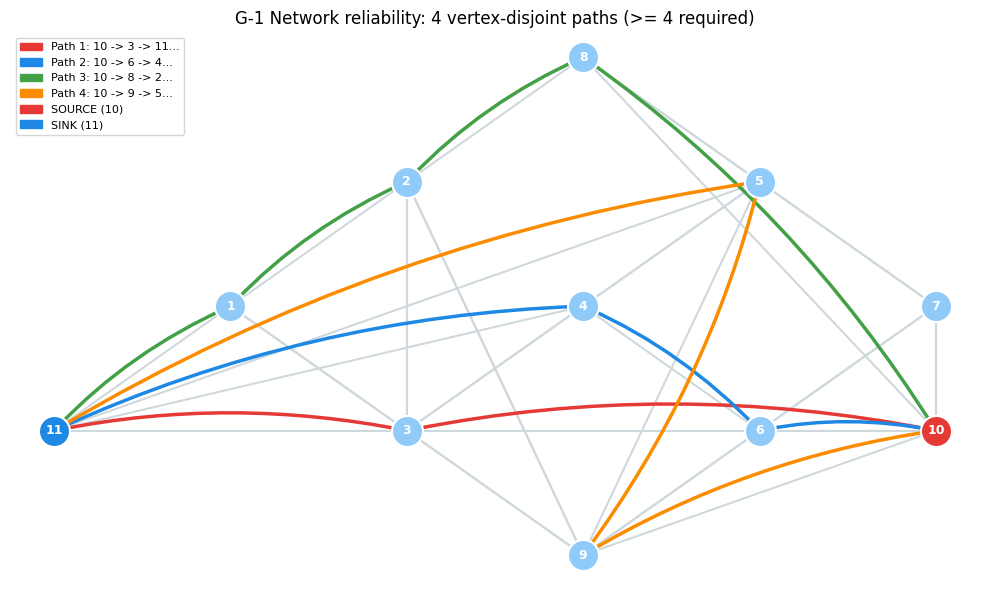

In [ ]:
if "paths" in locals():
    # Manual node positions for a readable layout
    node_pos = {
        1:(1,3), 2:(2,4), 3:(2,2), 4:(3,3), 5:(4,4), 6:(4,2),
        7:(5,3), 8:(3,5), 9:(3,1), 10:(5,2), 11:(0,2),
    }
    path_colors = ["#E53935","#1E88E5","#43A047","#FB8C00"]
    path_edges = set()
    for path in paths:
        for k in range(len(path)-1):
            path_edges.add((path[k], path[k+1]))

    fig, ax = plt.subplots(figsize=(10, 6))

    # Draw background edges
    all_arcs = set()
    for (n,m) in ARC:
        all_arcs.add((n,m)); all_arcs.add((m,n))
    for (n,m) in all_arcs:
        if (n,m) not in path_edges:
            x0,y0 = node_pos[n]; x1,y1 = node_pos[m]
            ax.plot([x0,x1],[y0,y1], color="#CFD8DC", lw=1.5, zorder=1)

    # Draw path edges
    for i, path in enumerate(paths):
        for k in range(len(path)-1):
            n, m = path[k], path[k+1]
            x0,y0 = node_pos[n]; x1,y1 = node_pos[m]
            ax.annotate("", xy=(x1,y1), xytext=(x0,y0),
                        arrowprops=dict(arrowstyle="->",color=path_colors[i],
                                        lw=2.5,connectionstyle="arc3,rad=0.1"))

    # Draw nodes
    for node, (x,y) in node_pos.items():
        color = "#E53935" if node==SOURCE else "#1E88E5" if node==SINK else "#90CAF9"
        ax.scatter(x, y, s=500, color=color, zorder=4, edgecolors="white", linewidths=1.5)
        ax.text(x, y, str(node), ha="center", va="center", fontsize=9,
                fontweight="bold", color="white", zorder=5)

    # Legend for paths
    legend = [mpatches.Patch(color=path_colors[i], label=f"Path {i+1}: {' -> '.join(str(n) for n in paths[i][:3])}...")
              for i in range(len(paths))]
    legend += [mpatches.Patch(color="#E53935",label="SOURCE (10)"),
               mpatches.Patch(color="#1E88E5",label="SINK (11)")]
    ax.legend(handles=legend, fontsize=8, loc="upper left")
    ax.set_title(f"G-1 Network reliability: {obj_val_g1:.0f} vertex-disjoint paths (>= 4 required)")
    ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping network chart")

## G-2 Mobile network dimensioning (MIP)

*Applications Book Chapter G, Example 2*

> **Mosel model:** [`g2dimens_p.mos`](models/telecomm/g2dimens_p.mos)

A mobile phone network has 10 cells that must each be connected to a 5-node hub ring: 4 simple hubs (nodes 1-4) and one MTSO (node 5). Each cell must make a fixed number of connections to the ring, constrained by ring capacity. The model minimizes total connection cost.

**Sets:** $\text{CELLS} = \{1, \ldots, 10\}$; $\text{NODES} = \{1, \ldots, 5\}$ (hubs 1-4 + MTSO 5)

**Parameters:** $\text{COST}_{c,n}$ - cost to connect cell $c$ to node $n$; $\text{TRAF}_c$ - traffic from cell $c$; $\text{CNCT}_c$ - required connections; $\text{CAP}$ - ring segment capacity

**Decision variables:** $\mathit{ifconnect}_{c,n} \in \{0,1\}$ - 1 if cell $c$ connected to node $n$

$$
\begin{align*}
\text{minimize}   \quad & \sum_{c,n} \text{COST}_{c,n} \cdot \mathit{ifconnect}_{c,n} \\
\text{subject to} \quad & \sum_n \mathit{ifconnect}_{c,n} = \text{CNCT}_c \quad \forall\, c \\
                          & \sum_{c,n \in \text{HUBS}} (\text{TRAF}_c / \text{CNCT}_c) \cdot \mathit{ifconnect}_{c,n} \leq 2 \cdot \text{CAP}
\end{align*}
$$

Define the cost matrix as a `pd.DataFrame` with cells as rows (1..10) and nodes as columns (1..5). Passing a DataFrame lets MoselPy map rows and columns directly to the Mosel 2D array `COST(CELLS, NODES)`. Traffic, connection counts, and ring capacity are 1-indexed dicts.

In [ ]:
cost_rows = [
    [15, 8, 7,11,10],
    [ 9,11, 8, 5,14],
    [12, 6, 7,15,15],
    [17, 5, 9,18,24],
    [ 8,22,21,19, 6],
    [ 7,25,15, 9,17],
    [19,25,21,20,22],
    [20, 9,15,18,25],
    [21,22,14,16,20],
    [25,24,13, 4,11],
]
COST_G2 = pd.DataFrame(cost_rows, index=range(1,11), columns=range(1,6))
COST_G2.index.name   = "Cell"
COST_G2.columns.name = "Node"

TRAF = {i: v for i, v in enumerate([22,12,20,12,15,25,15,14, 8,22], 1)}
CNCT = {i: v for i, v in enumerate([ 2, 2, 2, 2, 3, 1, 3, 2, 2, 2], 1)}
CAP_G2 = 48

print(f"Total traffic: {sum(TRAF.values())}  |  Ring capacity per segment: {CAP_G2}")
print(f"Maximum ring load (2*CAP): {2*CAP_G2}")
print(f"\nCost matrix (cells x nodes):")
print(COST_G2.to_string())

Total traffic: 165  |  Ring capacity per segment: 48
Maximum ring load (2*CAP): 96

Cost matrix (cells x nodes):
Node   1   2   3   4   5
Cell                    
1     15   8   7  11  10
2      9  11   8   5  14
3     12   6   7  15  15
4     17   5   9  18  24
5      8  22  21  19   6
6      7  25  15   9  17
7     19  25  21  20  22
8     20   9  15  18  25
9     21  22  14  16  20
10    25  24  13   4  11


Use the single execution command. `COST_G2` is passed as a DataFrame; MoselPy maps it to the Mosel 2D array. `CAP` is passed as a scalar via `input_data` to match the Mosel identifier name.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/g2dimens_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"COST": COST_G2, "TRAF": TRAF, "CNCT": CNCT, "CAP": CAP_G2},
)

if model.prob_status.is_solution_available:
    obj_val_g2    = output["obj_val"]
    sol_ifconnect = output["sol_ifconnect"]

    # Build assignment: cell -> list of connected nodes
    assignment = {c: [n for n in range(1,6) if sol_ifconnect.get((c,n),0) > 0.5]
                  for c in range(1,11)}

    print(f"Minimum connection cost: {obj_val_g2:.0f}")
    total_ring = sum(TRAF[c]/CNCT[c] * (sol_ifconnect.get((c,n),0) > 0.5)
                     for c in range(1,11) for n in range(1,5))
    print(f"Total ring traffic load: {total_ring:.1f} (limit: {2*CAP_G2})")
    print()
    for c in range(1, 11):
        nodes_str = " ".join(str(n) for n in assignment[c])
        cost_c = sum(cost_rows[c-1][n-1] for n in assignment[c])
        print(f"  Cell {c:>2} -> nodes [{nodes_str}]  cost={cost_c}")
else:
    print(f"No solution found ({model.prob_status})")

Minimum connection cost: 249
Total ring traffic load: 94.0 (limit: 96)

  Cell  1 -> nodes [3 5]  cost=17
  Cell  2 -> nodes [3 4]  cost=13
  Cell  3 -> nodes [2 5]  cost=21
  Cell  4 -> nodes [2 3]  cost=14
  Cell  5 -> nodes [1 4 5]  cost=33
  Cell  6 -> nodes [5]  cost=17
  Cell  7 -> nodes [1 4 5]  cost=61
  Cell  8 -> nodes [2 3]  cost=24
  Cell  9 -> nodes [3 5]  cost=34
  Cell 10 -> nodes [4 5]  cost=15


Grid showing which cells connect to which hub nodes. Each cell row shows its required number of connections (CNCT) as filled squares. Node 5 is the MTSO.

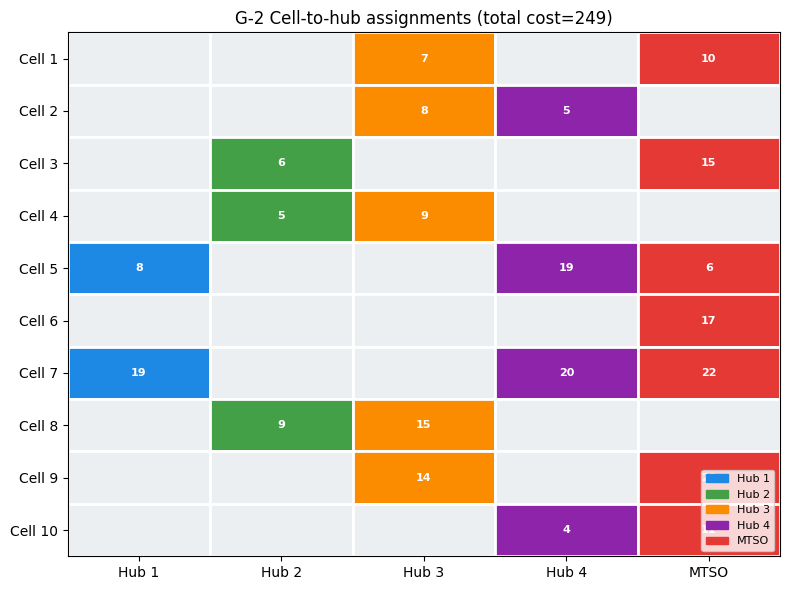

In [ ]:
if "assignment" in locals():
    fig, ax = plt.subplots(figsize=(8, 6))

    node_labels = {1:"Hub 1",2:"Hub 2",3:"Hub 3",4:"Hub 4",5:"MTSO"}
    colors = {"Hub 1":"#1E88E5","Hub 2":"#43A047","Hub 3":"#FB8C00","Hub 4":"#8E24AA","MTSO":"#E53935"}

    for c in range(1, 11):
        for n in range(1, 6):
            connected = sol_ifconnect.get((c,n),0) > 0.5
            color = list(colors.values())[n-1] if connected else "#ECEFF1"
            rect = plt.Rectangle((n-1, 11-c), 1, 1,
                                  facecolor=color, edgecolor="white", linewidth=2)
            ax.add_patch(rect)
            if connected:
                ax.text(n-0.5, 11-c+0.5, str(cost_rows[c-1][n-1]),
                        ha="center", va="center", fontsize=8, color="white", fontweight="bold")

    ax.set_xlim(0,5); ax.set_ylim(1,11)
    ax.set_xticks([0.5,1.5,2.5,3.5,4.5])
    ax.set_xticklabels([node_labels[n] for n in range(1,6)])
    ax.set_yticks([i+0.5 for i in range(1,11)])
    ax.set_yticklabels([f"Cell {11-i}" for i in range(1,11)])
    ax.set_title(f"G-2 Cell-to-hub assignments (total cost={obj_val_g2:.0f})")

    legend = [mpatches.Patch(color=c, label=l) for l,c in colors.items()]
    ax.legend(handles=legend, loc="lower right", fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping assignment grid")

## G-3 Routing telephone calls (MIP)

*Applications Book Chapter G, Example 3*

> **Mosel model:** [`g3routing_p.mos`](models/telecomm/g3routing_p.mos)

A private telephone network connects 5 French cities (Nantes, Nice, Paris, Troyes, Valenciennes) via 6 bidirectional arcs with known capacities. Five call demands between city pairs must be routed through the network. Each demand can be split across multiple paths. The model maximizes total routed traffic.

The model reads data in two `initializations from` blocks: the first populates arc capacities, demands, and the path-to-demand mapping; the second reads the route definitions once the number of arcs (`NARC`) is known.

**Sets:** $\text{CALLS}$ (city pairs, auto-populated from DEM); $\text{ARCS}$ (network links, auto-populated from CAP); $\text{PATHS} = \{1,\ldots,17\}$

**Decision variables:** $\mathit{flow}_p \geq 0$ integer - calls routed on path $p$

$$
\begin{align*}
\text{maximize}   \quad & \sum_{p} \mathit{flow}_p \\
\text{subject to} \quad & \sum_{p:\, \text{CINDEX}_p = d} \mathit{flow}_p \leq \text{DEM}_d \quad \forall\, d \in \text{CALLS} \\
                          & \sum_{p,b:\, \text{ROUTE}_{p,b} = a} \mathit{flow}_p \leq \text{CAP}_a \quad \forall\, a \in \text{ARCS}
\end{align*}
$$

Define arc capacities `CAP` and call demands `DEM` as string-keyed dicts. The `CINDEX` dict maps each path index to its demand pair. The route array `ROUTE` uses `(path, arc_position)` tuple keys; only non-empty positions need to be specified (Mosel string arrays default to `""`).

In [ ]:
CAP = {
    "Nantes-Paris":300, "Nantes-Nice":120, "Paris-Nice":300,
    "Paris-Valenciennes":200, "Troyes-Nice":80, "Troyes-Valenciennes":70,
}
DEM = {
    "Nantes-Nice":100, "Nantes-Troyes":80, "Nantes-Valenciennes":75,
    "Nice-Valenciennes":100, "Paris-Troyes":70,
}
CINDEX = {
    1:"Nantes-Nice",   2:"Nantes-Nice",   3:"Nantes-Nice",
    4:"Nantes-Troyes", 5:"Nantes-Troyes", 6:"Nantes-Troyes", 7:"Nantes-Troyes",
    8:"Nantes-Valenciennes", 9:"Nantes-Valenciennes",
    10:"Nantes-Valenciennes",11:"Nantes-Valenciennes",
    12:"Nice-Valenciennes",  13:"Nice-Valenciennes", 14:"Nice-Valenciennes",
    15:"Paris-Troyes", 16:"Paris-Troyes", 17:"Paris-Troyes",
}
routes_raw = {
    1: ["Nantes-Nice"],
    2: ["Nantes-Paris","Paris-Nice"],
    3: ["Nantes-Paris","Paris-Valenciennes","Valenciennes-Troyes","Troyes-Nice"],
    4: ["Nantes-Paris","Paris-Valenciennes","Valenciennes-Troyes"],
    5: ["Nantes-Paris","Paris-Nice","Troyes-Nice"],
    6: ["Nantes-Nice","Troyes-Nice"],
    7: ["Nantes-Nice","Paris-Nice","Paris-Valenciennes","Valenciennes-Troyes"],
    8: ["Nantes-Paris","Paris-Valenciennes"],
    9: ["Nantes-Nice","Paris-Nice","Paris-Valenciennes"],
    10:["Nantes-Paris","Paris-Nice","Troyes-Nice","Valenciennes-Troyes"],
    11:["Nantes-Nice","Troyes-Nice","Valenciennes-Troyes"],
    12:["Nantes-Nice","Nantes-Paris","Paris-Valenciennes"],
    13:["Paris-Nice","Paris-Valenciennes"],
    14:["Troyes-Nice","Valenciennes-Troyes"],
    15:["Paris-Valenciennes","Valenciennes-Troyes"],
    16:["Nantes-Paris","Nantes-Nice","Troyes-Nice"],
    17:["Paris-Nice","Troyes-Nice"],
}
# Only non-empty (path, arc_position) entries needed - string arrays default to ""
ROUTE = {(p, b+1): arc for p, arcs in routes_raw.items() for b, arc in enumerate(arcs)}

print(f"Demands: {len(DEM)} city pairs  |  Arcs: {len(CAP)}  |  Paths: {len(routes_raw)}")
print(f"Total demand: {sum(DEM.values())} calls")

Demands: 5 city pairs  |  Arcs: 6  |  Paths: 17
Total demand: 425 calls


Use the compile-load-run sequence. The model reads data in two consecutive `initializations from "moselpy:"` blocks. Both blocks draw from the same `input_data` dict; the second block reads `ROUTE` after the model has computed `NARC = getsize(ARCS)` from the first block.

In [ ]:
mp.compile_model(f"{MODELS}/g3routing_p.mos", f"{MODELS}/g3routing_p.bim")
model = mp.load_model(f"{MODELS}/g3routing_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"CAP": CAP, "DEM": DEM, "CINDEX": CINDEX, "ROUTE": ROUTE},
)

if model.prob_status.is_solution_available:
    obj_val_g3 = output["obj_val"]
    sol_flow   = output["sol_flow"]
    sol_route  = output["sol_route"]

    print(f"Total routed calls: {obj_val_g3:.0f}  (total demand: {sum(DEM.values())})")
    print()
    for demand, dem_val in sorted(DEM.items()):
        routed = sum(sol_flow.get(p,0) for p,d in CINDEX.items() if d==demand)
        unmet  = dem_val - routed
        print(f"  {demand:<25}  demand={dem_val:>3}  routed={routed:.0f}"
              + (f"  UNMET={unmet:.0f}" if unmet > 0.5 else ""))
        for p in sorted(k for k,d in CINDEX.items() if d==demand and sol_flow.get(k,0) > 0.5):
            arcs = [sol_route.get((p,b+1),"") for b in range(6) if sol_route.get((p,b+1),"")]
            print(f"    Path {p:>2}: {sol_flow[p]:.0f} calls via {' | '.join(arcs)}")
else:
    print(f"No solution found ({model.prob_status})")

Total routed calls: 380  (total demand: 425)

  Nantes-Nice                demand=100  routed=100
    Path  2: 100 calls via Nantes-Paris | Paris-Nice
  Nantes-Troyes              demand= 80  routed=80
    Path  7: 80 calls via Nantes-Nice | Paris-Nice | Paris-Valenciennes | Valenciennes-Troyes
  Nantes-Valenciennes        demand= 75  routed=40  UNMET=35
    Path  9: 40 calls via Nantes-Nice | Paris-Nice | Paris-Valenciennes
  Nice-Valenciennes          demand=100  routed=90  UNMET=10
    Path 13: 10 calls via Paris-Nice | Paris-Valenciennes
    Path 14: 80 calls via Troyes-Nice | Valenciennes-Troyes
  Paris-Troyes               demand= 70  routed=70
    Path 15: 70 calls via Paris-Valenciennes | Valenciennes-Troyes


Bar chart comparing demand vs routed calls for each city pair. Unmet demand is shown as a lighter overlay.

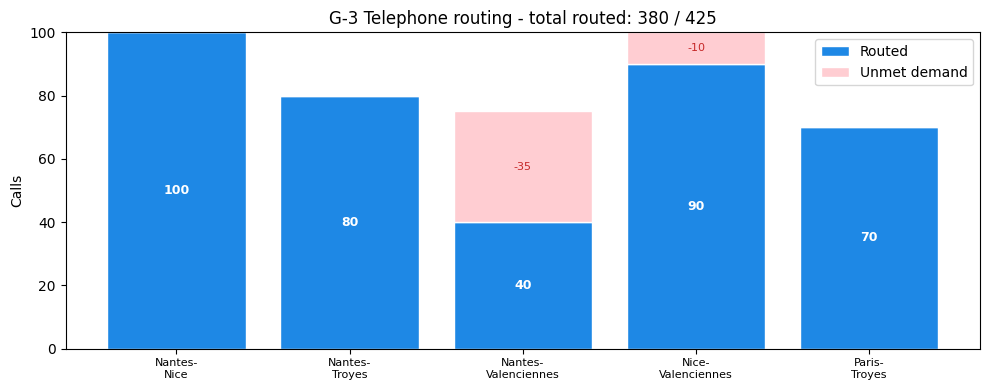

In [ ]:
if "sol_flow" in locals():
    demands_list = sorted(DEM.keys())
    routed_vals  = []
    unmet_vals   = []
    for demand in demands_list:
        routed = sum(sol_flow.get(p,0) for p,d in CINDEX.items() if d==demand)
        routed_vals.append(routed)
        unmet_vals.append(DEM[demand] - routed)

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(demands_list))
    ax.bar(x, routed_vals, color="#1E88E5", edgecolor="white", label="Routed")
    ax.bar(x, unmet_vals, bottom=routed_vals, color="#FFCDD2", edgecolor="white",
           label="Unmet demand")

    for i, (r, u) in enumerate(zip(routed_vals, unmet_vals)):
        ax.text(i, r/2, f"{r:.0f}", ha="center", va="center", fontsize=9,
                color="white", fontweight="bold")
        if u > 0:
            ax.text(i, r + u/2, f"-{u:.0f}", ha="center", va="center",
                    fontsize=8, color="#C62828")

    ax.set_xticks(x)
    ax.set_xticklabels([d.replace("-","-\n") for d in demands_list], fontsize=8)
    ax.set_ylabel("Calls")
    ax.set_title(f"G-3 Telephone routing - total routed: {obj_val_g3:.0f} / {sum(DEM.values())}")
    ax.legend()
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping routing chart")

## G-4 Cabled network (MIP)

*Applications Book Chapter G, Example 4*

> **Mosel model:** [`g4cable_p.mos`](models/telecomm/g4cable_p.mos)

A university wants to connect 6 terminal buildings with underground cables. Cables must form a connected spanning tree (no closed loops). A simple degree constraint is insufficient to avoid sub-cycles, so each node is assigned a level variable used in additional linear constraints to enforce a spanning tree structure rooted at terminal 1.

**Sets:** $\text{TERMINALS} = \{1, \ldots, 6\}$

**Parameters:** $\text{DIST}_{s,t}$ - distance between terminals (meters)

**Decision variables:** $\mathit{ifconnect}_{s,t} \in \{0,1\}$; $\mathit{level}_t \geq 0$

$$
\begin{align*}
\text{minimize}   \quad & \sum_{s \neq t} \text{DIST}_{s,t} \cdot \mathit{ifconnect}_{s,t} \\
\text{subject to} \quad & \sum_{s \neq t} \mathit{ifconnect}_{s,t} = 5 \quad (\text{spanning tree}) \\
                          & \sum_{t \neq s} \mathit{ifconnect}_{s,t} = 1 \quad \forall\, s \in \{2,\ldots,6\} \quad (\text{each non-root connects once}) \\
                          & \mathit{level}_t \geq \mathit{level}_s + 1 - 6 + 6 \cdot \mathit{ifconnect}_{s,t} \quad (\text{no sub-cycles})
\end{align*}
$$

Define the 6x6 distance matrix as a Python dict with `(s,t)` tuple keys. The matrix is symmetric; all 30 off-diagonal entries are provided.

In [ ]:
dist_rows = [
    [  0, 120,  92, 265, 149, 194],
    [120,   0, 141, 170,  93, 164],
    [ 92, 141,   0, 218, 103, 116],
    [265, 170, 218,   0, 110, 126],
    [149,  93, 103, 110,   0,  72],
    [194, 164, 116, 126,  72,   0],
]
DIST_G4 = {(i+1, j+1): dist_rows[i][j] for i in range(6) for j in range(6)}

print("Distance matrix (meters):")
dm = pd.DataFrame(dist_rows, index=range(1,7), columns=range(1,7))
dm.index.name = dm.columns.name = "Terminal"
print(dm.to_string())

Distance matrix (meters):
Terminal    1    2    3    4    5    6
Terminal                              
1           0  120   92  265  149  194
2         120    0  141  170   93  164
3          92  141    0  218  103  116
4         265  170  218    0  110  126
5         149   93  103  110    0   72
6         194  164  116  126   72    0


Use the compile-load-run sequence. Before running the model, inspect its metadata using `model.name`, `model.version`, and `model.size` - these properties are available immediately after `load_model()` without executing the model.

In [ ]:
mp.compile_model(f"{MODELS}/g4cable_p.mos", f"{MODELS}/g4cable_p.bim")
model = mp.load_model(f"{MODELS}/g4cable_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

print("Model metadata (before run):")
print(f"  name:    {model.name}")
print(f"  version: {model.version}")
print(f"  size:    {model.size:,} bytes")
print()

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"DIST": DIST_G4},
)

if model.prob_status.is_solution_available:
    obj_val_g4    = output["obj_val"]
    sol_ifconnect = output["sol_ifconnect"]

    edges = [(s,t) for s in range(1,7) for t in range(1,7)
             if s != t and sol_ifconnect.get((s,t),0) > 0.5]

    print(f"Minimum cable length: {obj_val_g4:.0f} meters")
    print(f"Connections (directed, rooted at terminal 1):")
    for s, t in sorted(edges):
        print(f"  Terminal {s} -> Terminal {t}  ({dist_rows[s-1][t-1]} m)")
else:
    print(f"No solution found ({model.prob_status})")

Model metadata (before run):
  name:    G-4 Cabled network
  version: 0
  size:    9,248 bytes

Minimum cable length: 470 meters
Connections (directed, rooted at terminal 1):
  Terminal 2 -> Terminal 5  (93 m)
  Terminal 3 -> Terminal 1  (92 m)
  Terminal 4 -> Terminal 5  (110 m)
  Terminal 5 -> Terminal 3  (103 m)
  Terminal 6 -> Terminal 5  (72 m)


Spanning tree visualization. Terminals are arranged by distance from the root (terminal 1). Selected cable connections are shown as solid lines.

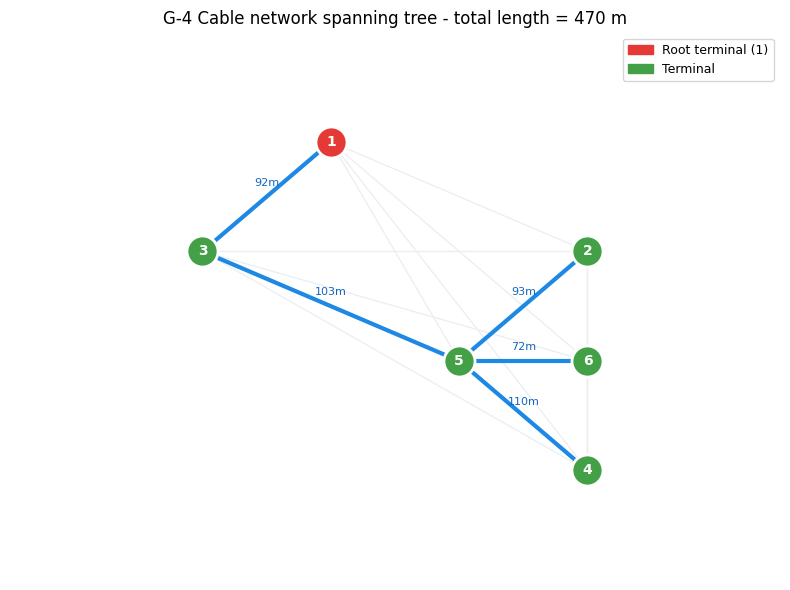

In [ ]:
if "edges" in locals():
    import math
    fig, ax = plt.subplots(figsize=(8, 6))

    # Manual positions for a clear spanning tree layout
    tpos = {1:(3,4), 2:(5,3), 3:(2,3), 4:(5,1), 5:(4,2), 6:(5,2)}

    # Draw all terminal pairs (light background)
    for s in range(1,7):
        for t in range(s+1,7):
            x0,y0 = tpos[s]; x1,y1 = tpos[t]
            ax.plot([x0,x1],[y0,y1], color="#ECEFF1", lw=1, zorder=1)

    # Draw cable connections
    for s,t in edges:
        x0,y0 = tpos[s]; x1,y1 = tpos[t]
        ax.plot([x0,x1],[y0,y1], color="#1E88E5", lw=3, zorder=2)
        mx, my = (x0+x1)/2, (y0+y1)/2
        ax.text(mx, my+0.08, f"{dist_rows[s-1][t-1]}m", ha="center", va="bottom",
                fontsize=8, color="#1565C0")

    # Draw terminals
    for t, (x,y) in tpos.items():
        color = "#E53935" if t==1 else "#43A047"
        ax.scatter(x, y, s=500, color=color, zorder=4, edgecolors="white", linewidths=2)
        ax.text(x, y, str(t), ha="center", va="center", fontsize=10,
                fontweight="bold", color="white", zorder=5)

    root_p = mpatches.Patch(color="#E53935", label="Root terminal (1)")
    term_p = mpatches.Patch(color="#43A047", label="Terminal")
    ax.legend(handles=[root_p, term_p], fontsize=9)
    ax.set_title(f"G-4 Cable network spanning tree - total length = {obj_val_g4:.0f} m")
    ax.set_xlim(0.5,6.5); ax.set_ylim(0,5); ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping cable network chart")

## G-5 Satellite scheduling (iterative MIP)

*Applications Book Chapter G, Example 5*

> **Mosel model:** [`g5satell_p.mos`](models/telecomm/g5satell_p.mos)

A satellite serves 4 U.S. transmitters and 4 European receivers. In each time slot (mode), each transmitter is paired with exactly one receiver. A mode duration equals the minimum traffic packet that can be served. The model uses the Gonzalez-Sahni algorithm: it transforms the traffic matrix into a quasi-bistochastic form, then iteratively solves a matching MIP to find the longest serviceable packet, updates the traffic matrix, and repeats until all traffic is served.

The entire iterative algorithm runs inside a single Mosel model execution. MoselPy calls `execute_model()` once and receives the complete schedule as output.

**Sets:** $\text{TRANSM} = \{1,\ldots,4\}$; $\text{RECV} = \{1,\ldots,4\}$; $\text{MODES}$ (dynamic range, grows per iteration)

**Decision variables per iteration:** $\mathit{flow}_{t,r} \in \{0,1\}$ (transmitter-receiver pairing); $\mathit{pmin} \geq 0$ (mode duration)

Define the 4x4 traffic matrix `TRAF` as a dict with `(transmitter, receiver)` tuple keys. Traffic values represent units of data to be transmitted between each station pair.

In [ ]:
traf_raw = [
    [ 0,  7, 11, 15],
    [15,  8, 13,  9],
    [17, 12,  6, 10],
    [ 6, 13, 15,  4],
]
TRAF_G5 = {(i+1, j+1): traf_raw[i][j] for i in range(4) for j in range(4)}

traf_df = pd.DataFrame(traf_raw, index=[f"T{i+1}" for i in range(4)],
                       columns=[f"R{j+1}" for j in range(4)])
traf_df.index.name = "Transmitter"
traf_df.columns.name = "Receiver"
print("Traffic matrix (units to transmit):")
print(traf_df.to_string())
print(f"Total traffic: {sum(traf_raw[i][j] for i in range(4) for j in range(4))}")

Traffic matrix (units to transmit):
Receiver     R1  R2  R3  R4
Transmitter                
T1            0   7  11  15
T2           15   8  13   9
T3           17  12   6  10
T4            6  13  15   4
Total traffic: 161


Use the context manager form of `mp.load_model()`. The iterative algorithm inside the Mosel model solves multiple MIP problems in a `while` loop, updating the traffic matrix after each mode until all traffic is scheduled. Python receives the complete schedule (mode durations and pairings) in a single `output` dict.

In [ ]:
mp.compile_model(f"{MODELS}/g5satell_p.mos", f"{MODELS}/g5satell_p.bim")

with mp.load_model(f"{MODELS}/g5satell_p.bim") as model:
    model.set_default_stream(mp.StreamType.OUTPUT, "null:")
    output = model.run(
        exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
        input_data={"TRAF": TRAF_G5},
    )
    prob_ok = model.prob_status.is_solution_available
# model resources freed here

if prob_ok:
    obj_val_g5 = output["obj_val"]
    solpmin   = output["solpmin"]
    solflowt  = output["solflowt"]   # solflowt[(t,m)] = transmitter t (= t)
    solflowr  = output["solflowr"]   # solflowr[(t,m)] = receiver paired with t in mode m

    nmodes = max(m for (t,m) in solflowr.keys())
    schedule = {(t, m): int(solflowr.get((t,m),0)) for t in range(1,5) for m in range(1,nmodes+1)}

    print(f"Total schedule duration: {obj_val_g5:.0f}")
    print(f"Number of modes: {nmodes}")
    print()
    print(f"{'Mode':>5}  {'Duration':>9}  {'T1->':>5}  {'T2->':>5}  {'T3->':>5}  {'T4->':>5}")
    cumtime = 0
    for m in range(1, nmodes+1):
        dur = int(solpmin.get(m,0))
        pairs = [f"R{schedule[(t,m)]}" if schedule[(t,m)] > 0 else "  -" for t in range(1,5)]
        print(f"  {m:>3}    {cumtime:>4}-{cumtime+dur:<4}   {'  '.join(pairs)}")
        cumtime += dur
else:
    print("No solution found")

Total schedule duration: 45
Number of modes: 8

 Mode   Duration   T1->   T2->   T3->   T4->
    1       0-13     R4  R3  R1  R2
    2      13-24     R3  R1  R2  R4
    3      24-31     R1  R2  R4  R3
    4      31-37     R2  R4  R3  R1
    5      37-40     R2  R4  R1  R3
    6      40-43     R2  R1  R4  R3
    7      43-44     R4  R2  R1  R3
    8      44-45     R4  R1  R2  R3


Gantt chart of the satellite schedule. Each row represents one transmitter; colored blocks show which receiver it is paired with in each mode. Block width is proportional to mode duration.

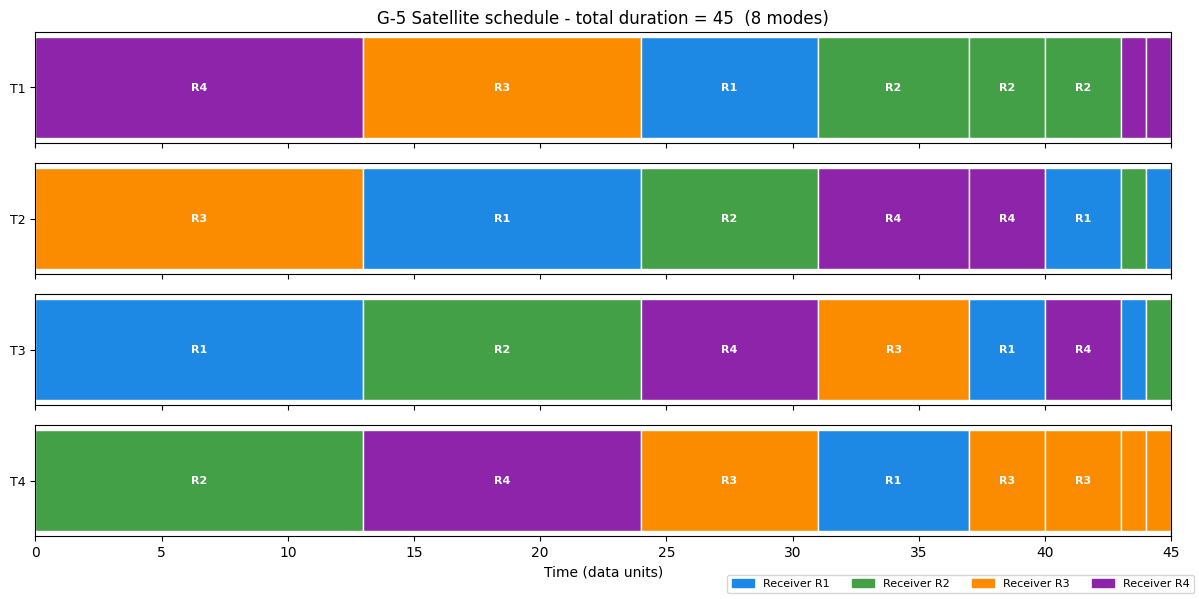

In [ ]:
if "schedule" in locals():
    recv_colors = {1:"#1E88E5", 2:"#43A047", 3:"#FB8C00", 4:"#8E24AA"}

    fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)

    for t in range(1, 5):
        ax = axes[t-1]
        cumtime = 0
        for m in range(1, nmodes+1):
            dur  = int(solpmin.get(m, 0))
            recv = schedule[(t, m)]
            color = recv_colors.get(recv, "#90CAF9")
            ax.barh(0, dur, left=cumtime, height=0.7, color=color, edgecolor="white")
            if dur >= 2:
                ax.text(cumtime + dur/2, 0, f"R{recv}", ha="center", va="center",
                        fontsize=8, color="white", fontweight="bold")
            cumtime += dur
        ax.set_yticks([0])
        ax.set_yticklabels([f"T{t}"], fontsize=9)
        ax.set_xlim(0, obj_val_g5)
        ax.axvline(obj_val_g5, color="#90A4AE", lw=1, linestyle="--")

    axes[-1].set_xlabel("Time (data units)")
    axes[0].set_title(f"G-5 Satellite schedule - total duration = {obj_val_g5:.0f}  ({nmodes} modes)")

    legend = [mpatches.Patch(color=recv_colors[r], label=f"Receiver R{r}") for r in range(1,5)]
    fig.legend(handles=legend, loc="lower right", ncol=4, fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping Gantt chart")

## G-6 Transmitter placement (MIP)

*Applications Book Chapter G, Example 6*

> **Mosel model:** [`g6transmit_p.mos`](models/telecomm/g6transmit_p.mos)

A mobile phone operator plans to equip an uncovered region. There are 7 candidate transmitter locations. Each location can cover a subset of 15 communities with known populations. Which transmitters should be built to maximize total population covered, subject to a budget constraint?

The coverage data is sparse: only `(place, community)` pairs where `COVER(p,c) = 1` are specified; all other entries default to 0 in Mosel's dense array.

**Sets:** $\text{PLACES} = \{1,\ldots,7\}$; $\text{COMMS} = \{1,\ldots,15\}$

**Decision variables:** $\mathit{build}_p \in \{0,1\}$; $\mathit{covered}_c \in \{0,1\}$

$$
\begin{align*}
\text{maximize}   \quad & \sum_c \text{POP}_c \cdot \mathit{covered}_c \\
\text{subject to} \quad & \sum_p \text{COVER}_{p,c} \cdot \mathit{build}_p \geq \mathit{covered}_c \quad \forall\, c \\
                          & \sum_p \text{COST}_p \cdot \mathit{build}_p \leq \text{BUDGET}
\end{align*}
$$

Define `COST` as a 1-indexed dict and `POP` as a 1-indexed dict. The `COVER` array is provided as a sparse dict with only the non-zero `(place, community)` entries. Mosel initializes the remaining 2D array entries to 0. `BUDGET` is an integer passed via `exec_params` to enable easy sensitivity analysis.

In [ ]:
COST_G6 = {i: v for i, v in enumerate([1.8, 1.3, 4.0, 3.5, 3.8, 2.6, 2.1], 1)}
POP_G6  = {i: v for i, v in enumerate([2,4,13,6,9,4,8,12,10,11,6,14,9,3,6], 1)}

# Sparse coverage: only (place, community) pairs that equal 1
cover_entries = [
    (1,1),(1,2),(1,4),
    (2,2),(2,3),(2,5),
    (3,4),(3,7),(3,8),(3,10),
    (4,5),(4,6),(4,8),(4,9),
    (5,8),(5,9),(5,12),
    (6,7),(6,10),(6,11),(6,12),(6,15),
    (7,12),(7,13),(7,14),(7,15),
]
COVER_G6 = {(p,c): 1 for p,c in cover_entries}

BUDGET_DEFAULT = 10

total_pop = sum(POP_G6.values())
print(f"Communities: 15  |  Candidate sites: 7  |  Total population: {total_pop}")
print(f"Default budget: {BUDGET_DEFAULT}  |  Total cost if all built: {sum(COST_G6.values()):.1f}")

Communities: 15  |  Candidate sites: 7  |  Total population: 117
Default budget: 10  |  Total cost if all built: 19.1


### Sensitivity analysis: varying BUDGET

Compile and load the model once. Run it multiple times with different `BUDGET` values via `exec_params`. Each run finds the maximum coverage achievable within the given budget. Results are collected into a `pd.Series` indexed by budget value.

In [ ]:
mp.compile_model(f"{MODELS}/g6transmit_p.mos", f"{MODELS}/g6transmit_p.bim")
model = mp.load_model(f"{MODELS}/g6transmit_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

# Parametric run: vary BUDGET
budget_values = [5, 6, 7, 8, 9, 10, 11, 12, 15]
sensitivity   = {}

for budget in budget_values:
    out = model.run(
        exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:", "BUDGET": budget},
        input_data={"COST": COST_G6, "COVER": COVER_G6, "POP": POP_G6},
    )
    if model.prob_status.is_solution_available:
        sensitivity[budget] = out["obj_val"]
    else:
        print(f"BUDGET={budget}: no solution ({model.prob_status})")

coverage_series = pd.Series(sensitivity, name="Population covered")
coverage_series.index.name = "Budget"
print("Coverage sensitivity:")
print(coverage_series.apply(lambda v: f"{v:.0f}").to_string())

# Best solution at default budget
out_default = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:", "BUDGET": BUDGET_DEFAULT},
    input_data={"COST": COST_G6, "COVER": COVER_G6, "POP": POP_G6},
)
if model.prob_status.is_solution_available:
    obj_val_g6   = out_default["obj_val"]
    sol_build    = out_default["sol_build"]
    sol_covered  = out_default["sol_covered"]
    built_sites  = [p for p in range(1,8) if sol_build.get(p,0) > 0.5]
    actual_cost  = sum(COST_G6[p] for p in built_sites)
    print()
    print(f"Default solution (budget={BUDGET_DEFAULT}): coverage={obj_val_g6:.0f}, "
          f"sites={built_sites}, cost={actual_cost:.1f}")

Coverage sensitivity:
Budget
5      71
6      83
7      84
8      97
9      97
10    109
11    109
12    117
15    117

Default solution (budget=10): coverage=109, sites=[2, 4, 6, 7], cost=9.5


Two-panel visualization: (left) coverage sensitivity curve vs budget; (right) coverage breakdown at the default budget showing which communities are covered and which are not.

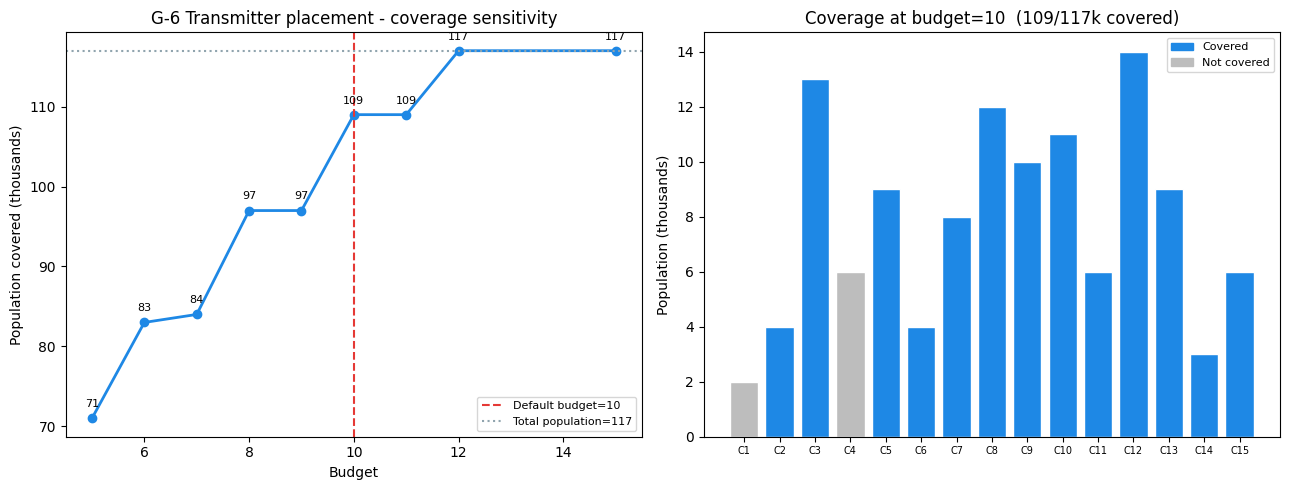

In [ ]:
if coverage_series is not None and not coverage_series.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: sensitivity curve
    ax = axes[0]
    ax.plot(coverage_series.index, coverage_series.values,
            marker="o", color="#1E88E5", linewidth=2)
    ax.axvline(BUDGET_DEFAULT, color="#E53935", linestyle="--", lw=1.5,
               label=f"Default budget={BUDGET_DEFAULT}")
    ax.axhline(total_pop, color="#90A4AE", linestyle=":", lw=1.5,
               label=f"Total population={total_pop}")
    for b, v in sensitivity.items():
        ax.annotate(f"{v:.0f}", (b, v), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=8)
    ax.set_xlabel("Budget"); ax.set_ylabel("Population covered (thousands)")
    ax.set_title("G-6 Transmitter placement - coverage sensitivity")
    ax.legend(fontsize=8)

    # Right: community coverage at default budget
    ax2 = axes[1]
    if "sol_covered" in locals():
        pops     = [POP_G6[c] for c in range(1,16)]
        covered  = [sol_covered.get(c,0) > 0.5 for c in range(1,16)]
        colors_c = ["#1E88E5" if cv else "#BDBDBD" for cv in covered]
        bars = ax2.bar(range(1,16), pops, color=colors_c, edgecolor="white")
        ax2.set_xticks(range(1,16))
        ax2.set_xticklabels([f"C{c}" for c in range(1,16)], fontsize=7)
        ax2.set_ylabel("Population (thousands)")
        ax2.set_title(f"Coverage at budget={BUDGET_DEFAULT}  ({obj_val_g6:.0f}/{total_pop}k covered)")
        cov_p = mpatches.Patch(color="#1E88E5", label="Covered")
        unc_p = mpatches.Patch(color="#BDBDBD", label="Not covered")
        ax2.legend(handles=[cov_p, unc_p], fontsize=8)

    plt.tight_layout(); plt.show()
else:
    print("No results available - skipping transmitter charts")